# House Price Prediction — Exploratory Data Analysis (EDA)

This notebook loads the California Housing dataset directly with
`sklearn.datasets.fetch_california_housing()` and does a first-pass
exploratory look at it: shape, a preview of the rows, summary
statistics, missing values, and the distribution of every numeric
column via histograms and boxplots.

**This notebook does not train any model and does not build the
Streamlit dashboard** — it's exploration only.


## 1. Imports

We need `pandas` for the data itself, `matplotlib`/`seaborn` for the
plots, and `fetch_california_housing` to load the dataset.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_style("whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

`fetch_california_housing(as_frame=True)` returns a scikit-learn
`Bunch`, whose `.frame` attribute is already a single pandas
DataFrame containing the 8 feature columns plus the target column,
`MedHouseVal`.


In [ ]:
housing_bunch = fetch_california_housing(as_frame=True)
housing_df = housing_bunch.frame

print(f"Dataset loaded: {housing_df.shape[0]} rows, {housing_df.shape[1]} columns.")


Dataset loaded: 20640 rows, 9 columns.


## 3. Shape

The number of rows (samples) and columns (8 features + 1 target).


In [ ]:
housing_df.shape

(20640, 9)

## 4. Head

A quick preview of the first 5 rows.


In [ ]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 5. Describe

Summary statistics (count, mean, std, min, quartiles, max) for
every numeric column.


In [ ]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 6. Missing Values

Checking whether any column has missing (NaN) values.


In [ ]:
missing_values = housing_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

total_missing = int(missing_values.sum())
print(f"\nTotal missing values in the dataset: {total_missing}")


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values in the dataset: 0


## 7. Histograms

A histogram for every numeric column (features + target), to see
each variable's distribution, range, and skew at a glance.


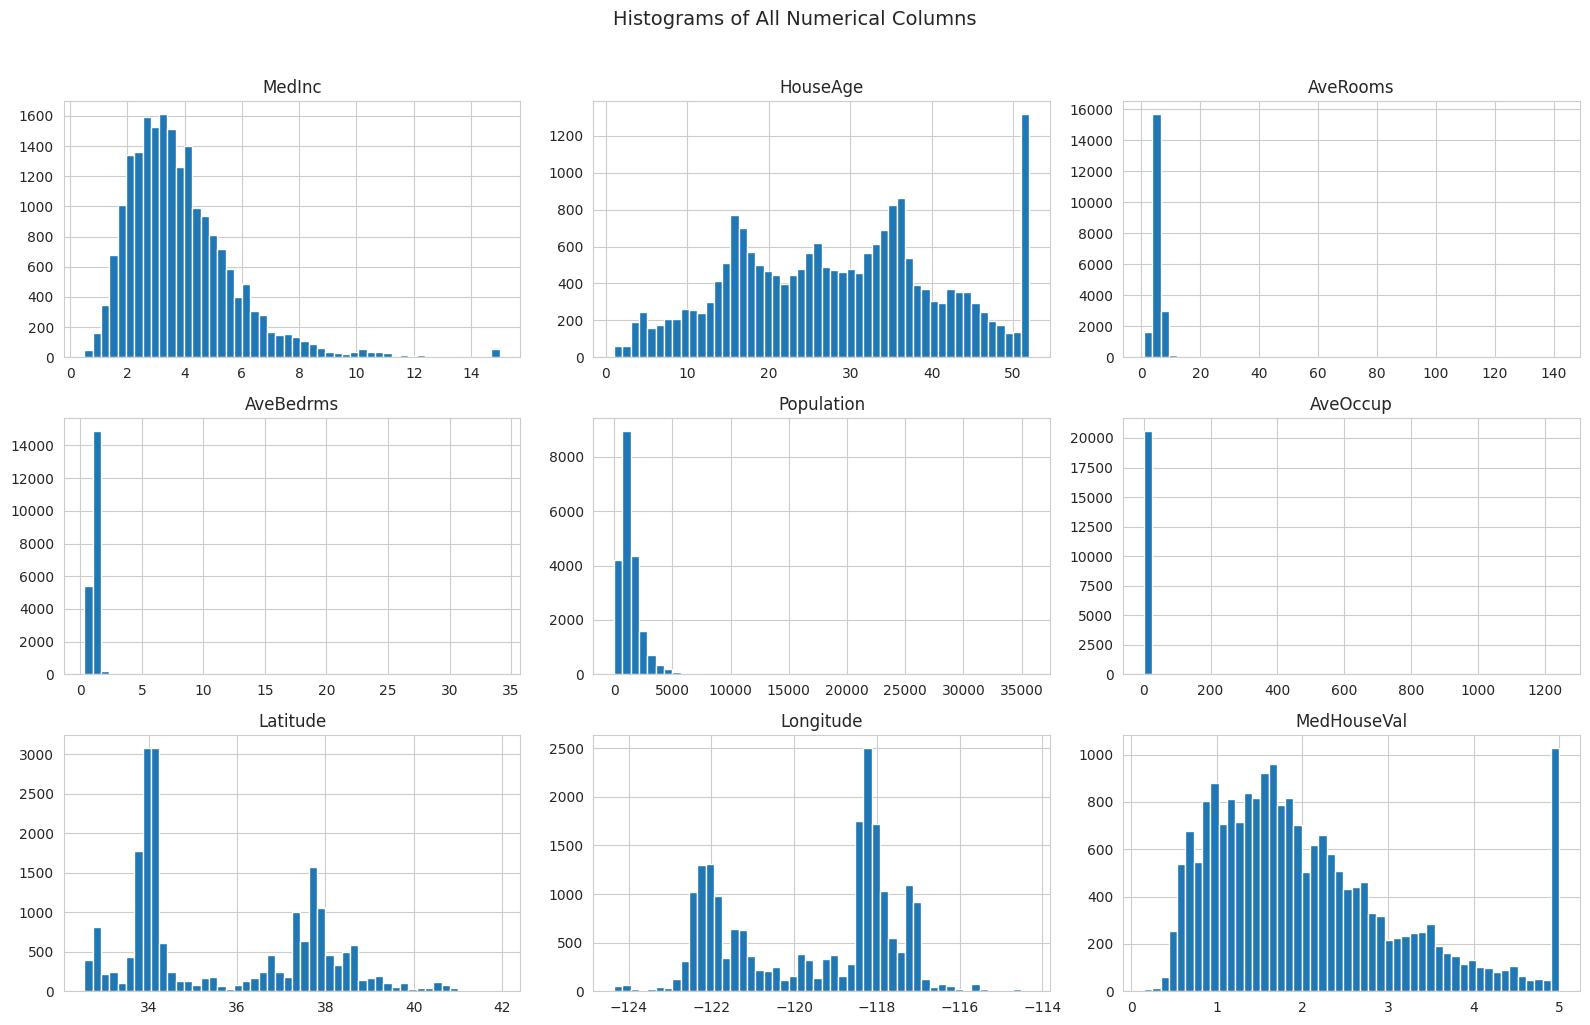

In [ ]:
housing_df.hist(bins=50, figsize=(16, 10))
plt.suptitle("Histograms of All Numerical Columns", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 8. Boxplots

A boxplot for every numeric column, to spot outliers and compare
each variable's spread more precisely than a histogram alone.
Since these columns are on very different scales, each gets its own
subplot rather than being plotted side by side.


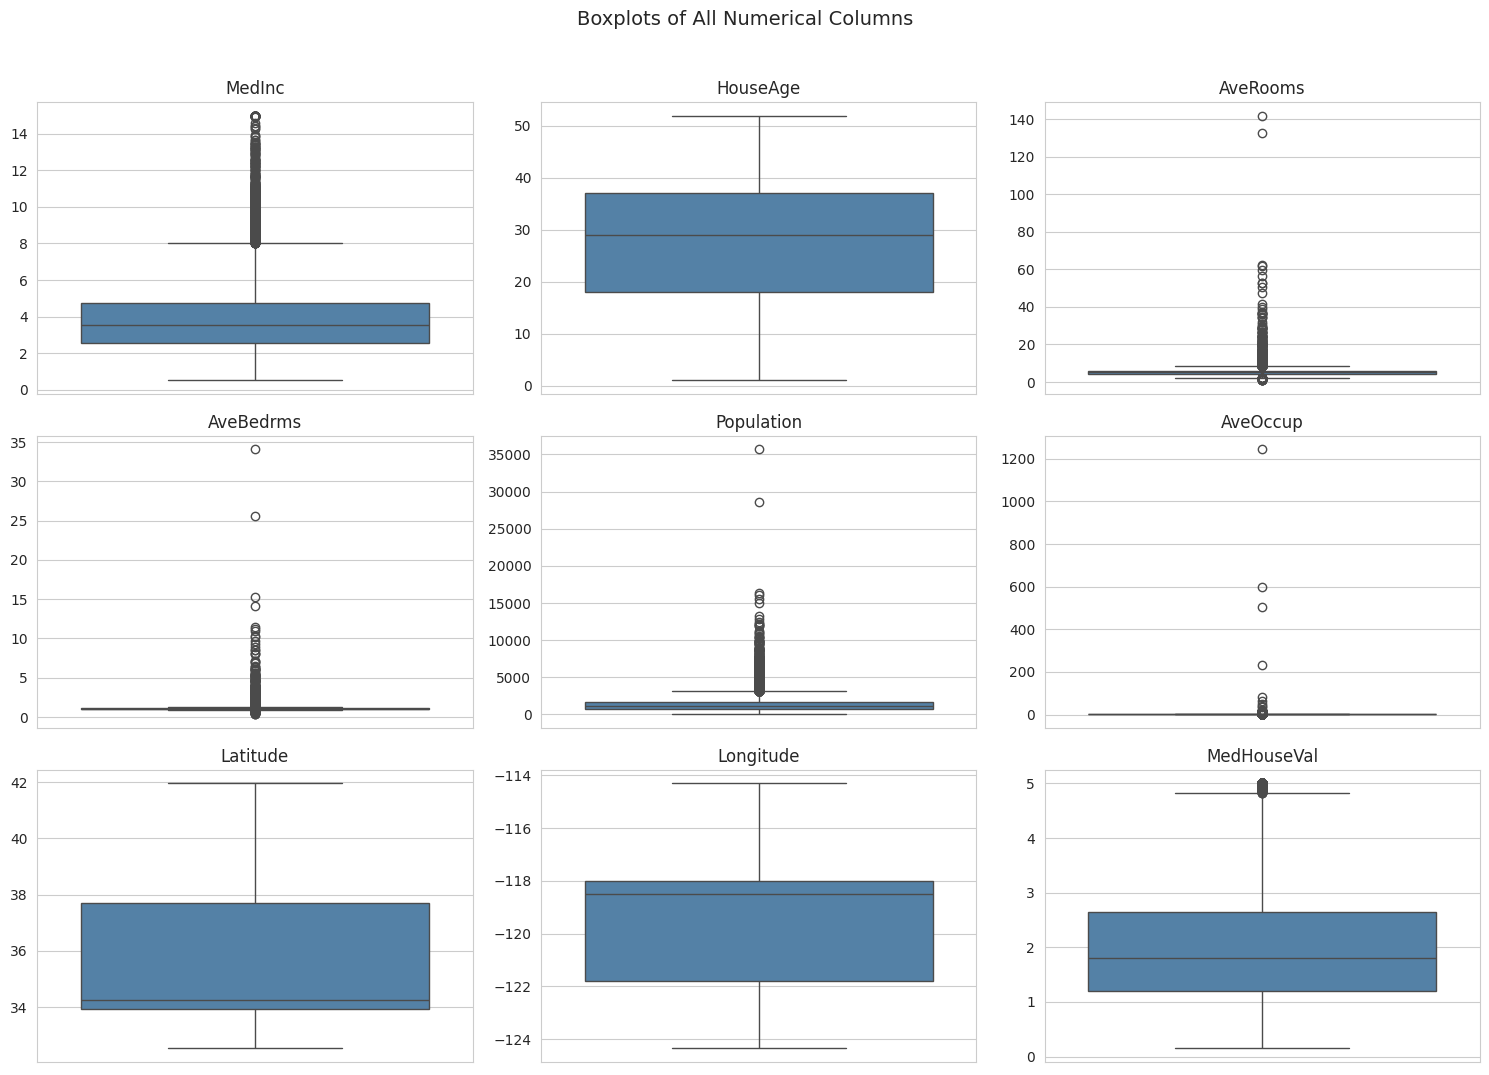

In [ ]:
numeric_columns = housing_df.columns.tolist()
num_cols = 3
num_rows = -(-len(numeric_columns) // num_cols)  # ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3.5))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(y=housing_df[column], ax=ax, color="steelblue")
    ax.set_title(column)
    ax.set_ylabel("")

# Hide any unused subplot axes
for ax in axes[len(numeric_columns):]:
    ax.axis("off")

plt.suptitle("Boxplots of All Numerical Columns", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 9. Correlation Heatmap

Now let's look at how the numeric columns relate to each other, using
the Pearson correlation coefficient (ranges from -1 to +1). We care
most about the bottom row / right column — the correlation of every
feature with the target, `MedHouseVal`.


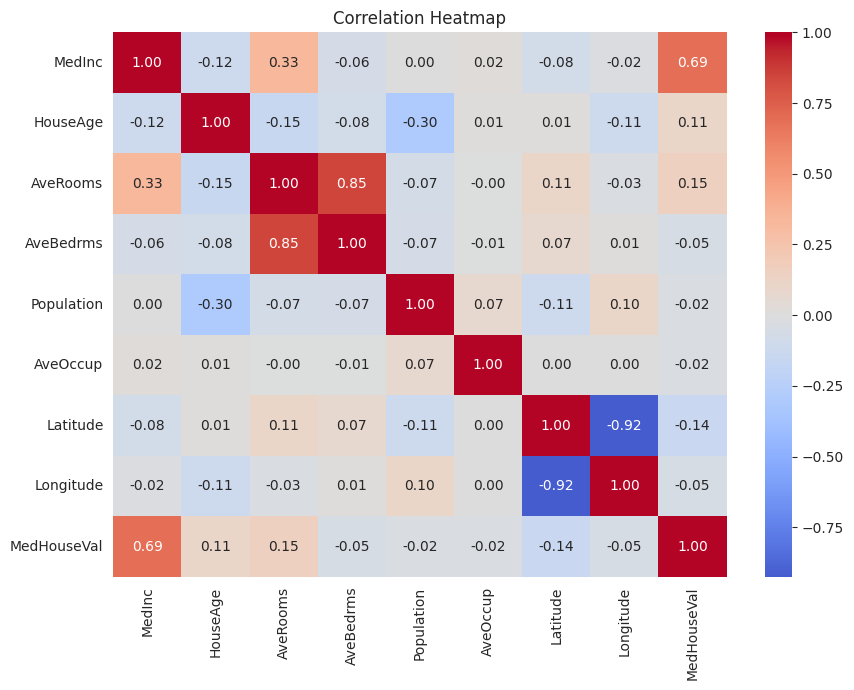

In [ ]:
correlation_matrix = housing_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Correlation with the target, sorted by strength** — this is the
number we'll rely on later for the "important features" section and
for picking which features go into the pairplot.


In [ ]:
correlation_with_target = (
    correlation_matrix["MedHouseVal"]
    .drop("MedHouseVal")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
correlation_with_target


MedInc        0.688075
AveRooms      0.151948
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
Name: MedHouseVal, dtype: float64

## 10. Scatter Plots vs. MedHouseVal

Correlation only captures *linear* relationships, so it's worth
looking directly at a few key features plotted against the target.
Points are drawn with transparency (`alpha`), since with 20,640
points, dense regions would otherwise just look like solid blobs.


**MedInc vs MedHouseVal** — income was the strongest correlation above, so this is the relationship we'd expect to look clearest.

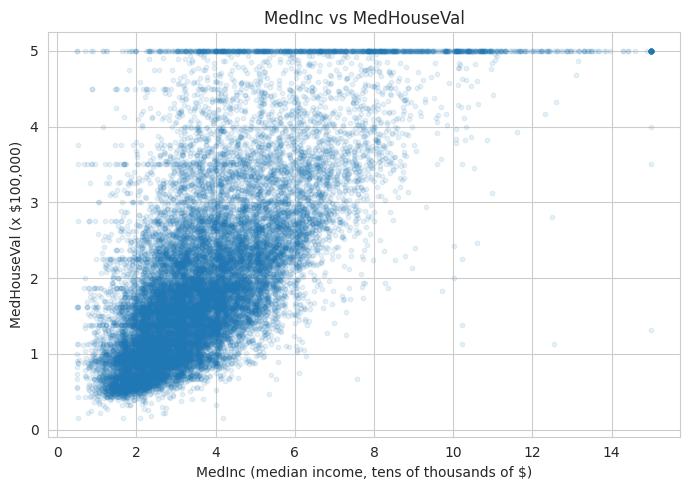

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(housing_df["MedInc"], housing_df["MedHouseVal"], alpha=0.1, s=10)
plt.xlabel("MedInc (median income, tens of thousands of $)")
plt.ylabel("MedHouseVal (x $100,000)")
plt.title("MedInc vs MedHouseVal")
plt.tight_layout()
plt.show()


**HouseAge vs MedHouseVal** — a much weaker relationship in the correlation table; let's see what that looks like visually.

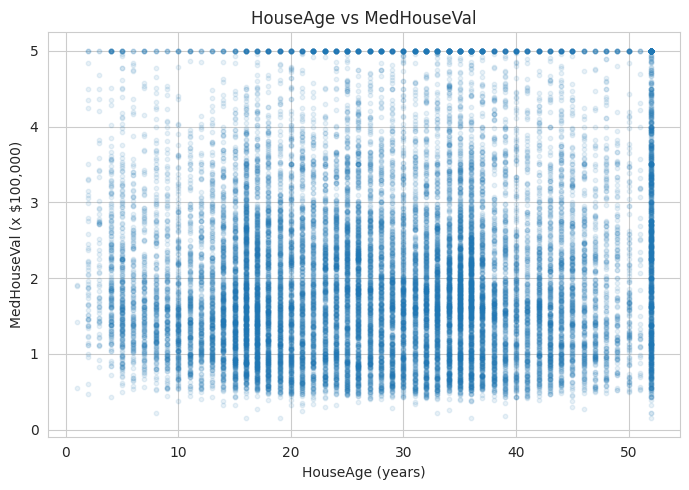

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(housing_df["HouseAge"], housing_df["MedHouseVal"], alpha=0.1, s=10)
plt.xlabel("HouseAge (years)")
plt.ylabel("MedHouseVal (x $100,000)")
plt.title("HouseAge vs MedHouseVal")
plt.tight_layout()
plt.show()


**Latitude vs MedHouseVal** — location isn't linear with price, but certain latitude bands (e.g. the SF Bay Area, LA) should stand out as more expensive.

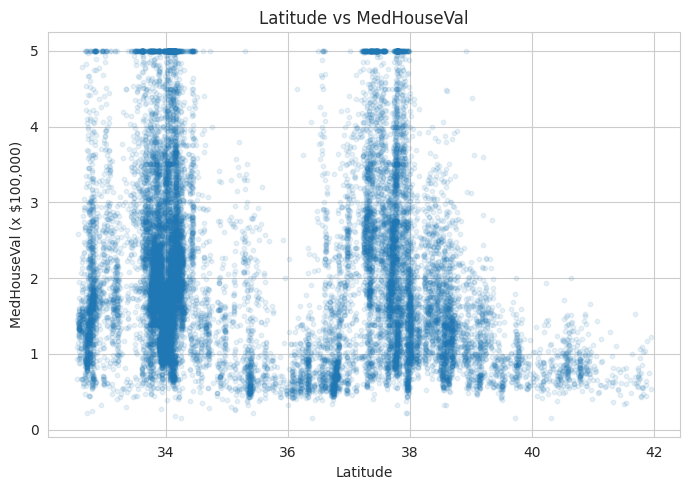

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(housing_df["Latitude"], housing_df["MedHouseVal"], alpha=0.1, s=10)
plt.xlabel("Latitude")
plt.ylabel("MedHouseVal (x $100,000)")
plt.title("Latitude vs MedHouseVal")
plt.tight_layout()
plt.show()


**Longitude vs MedHouseVal** — similarly, coastal longitudes (further west / more negative) should tend to be pricier.

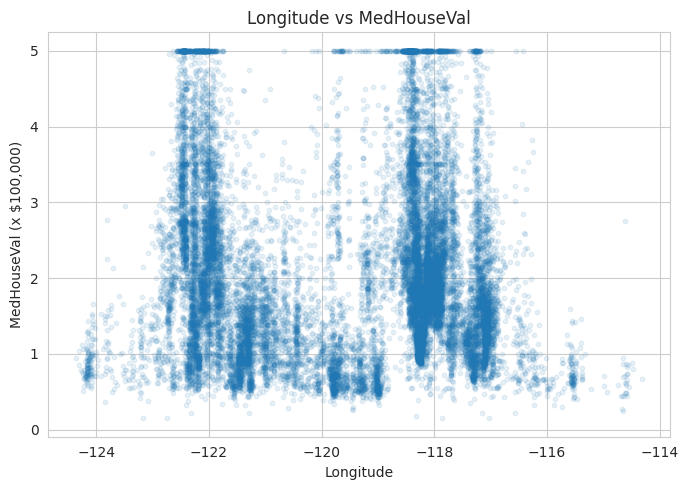

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(housing_df["Longitude"], housing_df["MedHouseVal"], alpha=0.1, s=10)
plt.xlabel("Longitude")
plt.ylabel("MedHouseVal (x $100,000)")
plt.title("Longitude vs MedHouseVal")
plt.tight_layout()
plt.show()


## 11. Pair Plot of Important Features

A pair plot of *all* 9 columns would be cluttered and slow to render,
so instead we use the top features identified by the correlation
heatmap above (the 3 features with the strongest absolute correlation
to `MedHouseVal`, selected programmatically — not hand-picked) plus
the target itself. We also plot a random sample of 1,500 rows rather
than all 20,640, purely so the plot renders quickly and stays
readable; the sample is large enough to show the same overall
patterns as the full dataset.


Features selected for the pair plot (by strongest |correlation| with MedHouseVal): ['MedInc', 'AveRooms', 'Latitude']


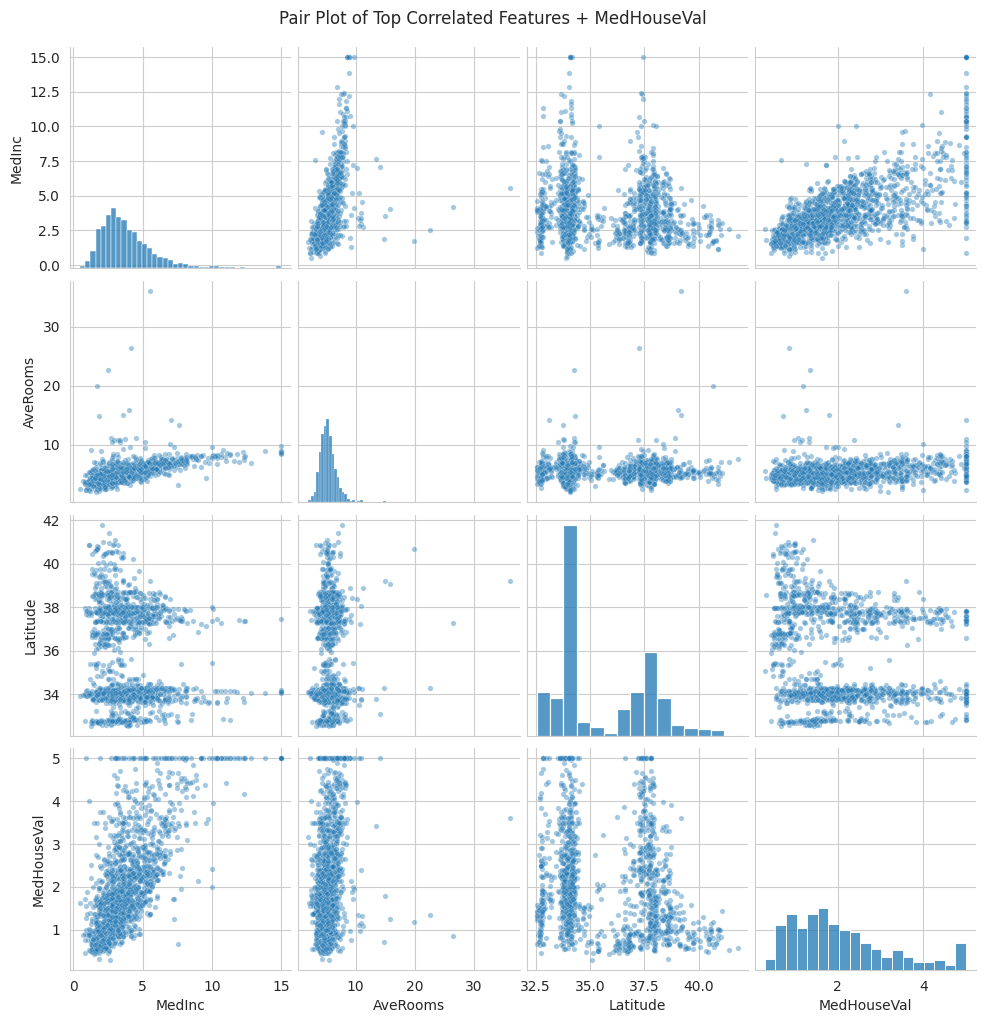

In [ ]:
top_features = correlation_with_target.abs().sort_values(ascending=False).head(3).index.tolist()
pairplot_columns = top_features + ["MedHouseVal"]
print("Features selected for the pair plot (by strongest |correlation| with MedHouseVal):", top_features)

sample_df = housing_df[pairplot_columns].sample(n=1500, random_state=42)

sns.pairplot(sample_df, diag_kind="hist", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pair Plot of Top Correlated Features + MedHouseVal", y=1.02)
plt.show()


## 12. EDA Findings

Before writing conclusions in prose, let's compute the actual numbers
those conclusions will be based on: correlation strength, skewness,
and how much of each column falls outside the typical IQR-based
outlier bounds.


In [ ]:
print("Correlation with MedHouseVal (sorted by strength):")
print(correlation_with_target)

print("\nSkewness of every column (0 = symmetric, higher = more right-skewed):")
skewness = housing_df.skew().sort_values(ascending=False)
print(skewness)

print("\nShare of values outside the 1.5*IQR range, per column:")
outlier_summary = {}
for column in housing_df.columns:
    q1, q3 = housing_df[column].quantile(0.25), housing_df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_share = ((housing_df[column] < lower_bound) | (housing_df[column] > upper_bound)).mean() * 100
    outlier_summary[column] = outlier_share
    print(f"  {column:12s}: {outlier_share:5.2f}%")

house_age_capped_share = (housing_df["HouseAge"] == 52).mean() * 100
med_house_val_capped_share = (housing_df["MedHouseVal"] >= 5.0).mean() * 100
print(f"\nRows with HouseAge exactly at the max (52): {house_age_capped_share:.2f}%")
print(f"Rows with MedHouseVal at/above the cap (5.0): {med_house_val_capped_share:.2f}%")


Correlation with MedHouseVal (sorted by strength):
MedInc        0.688075
AveRooms      0.151948
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
Name: MedHouseVal, dtype: float64

Skewness of every column (0 = symmetric, higher = more right-skewed):
AveOccup       97.639561
AveBedrms      31.316956
AveRooms       20.697869
Population      4.935858
MedInc          1.646657
MedHouseVal     0.977763
Latitude        0.465953
HouseAge        0.060331
Longitude      -0.297801
dtype: float64

Share of values outside the 1.5*IQR range, per column:
  MedInc      :  3.30%
  HouseAge    :  0.00%
  AveRooms    :  2.48%
  AveBedrms   :  6.90%
  Population  :  5.79%
  AveOccup    :  3.44%
  Latitude    :  0.00%
  Longitude   :  0.00%
  MedHouseVal :  5.19%

Rows with HouseAge exactly at the max (52): 6.17%
Rows with MedHouseVal at/above the cap (5.0): 4.81%


## 13. EDA Conclusions

**Strongest relationships with `MedHouseVal`.** `MedInc` is, by a wide
margin, the strongest linear predictor of house value (correlation
≈ **0.69**) — visible directly in the MedInc vs. MedHouseVal scatter
plot above, where higher income clearly pushes house values up (with
a visible ceiling effect at `MedHouseVal = 5.0`, the top-coded cap).
Every other feature correlates only weakly with the target:
`AveRooms` (≈0.15), `Latitude` (≈ -0.14), and `HouseAge` (≈0.11) are
the next strongest, and `AveBedrms`, `Longitude`, `Population`, and
`AveOccup` are all essentially uncorrelated with price on their own
(|corr| < 0.05).

**Important features.** Based on the correlation values above, `MedInc`
stands out as the single most important feature for predicting price.
`AveRooms`, `Latitude`, and `HouseAge` are secondary but still the
next-most-informative individually — `Latitude`'s scatter plot shows
visible spikes in value around specific latitude bands (the Bay Area
and Los Angeles), which a single linear correlation number
understates, since the relationship with location is clearly
non-linear.

**Possible outliers.** The three "per-household average" columns —
`AveRooms`, `AveBedrms`, and especially `AveOccup` — contain extreme
outliers: `AveOccup` ranges up to about 1,243 despite a typical value
of only a few people per household, and `AveRooms`/`AveBedrms` show
similar extreme maximums. This happens because these are *averages*
computed by dividing by the number of households in a block group —
a block group with very few households (e.g. a mostly-vacant resort
area) can produce a huge average. `Population` also has a long right
tail (a handful of unusually large block groups). By contrast,
`Latitude`, `Longitude`, and `HouseAge` show **0%** values outside
their IQR-based bounds — they are naturally well-contained by
geography and the dataset's age cap.

**Skewed distributions.** Skewness confirms the same picture:
`AveOccup`, `AveBedrms`, and `AveRooms` are extremely right-skewed
(skewness in the double digits, driven by the same few extreme
block groups noted above), `Population` is moderately right-skewed,
and `MedInc`/`MedHouseVal` are mildly right-skewed. `HouseAge` is
close to symmetric.

**Two artificial "capping" effects are visible in the data**, both
consistent with how the original 1990 census data was top-coded:
about **6%** of rows have `HouseAge` exactly at its maximum value of
52 (a spike clearly visible in the Section 7 histogram), and about
**5%** of rows have `MedHouseVal` at or above its cap of 5.0 (also
visible as a spike at the right edge of that histogram). Both should
be kept in mind for later modeling — capped target values in
particular can distort a regression model's error metrics for the
most expensive block groups.

**Overall:** this dataset is dominated by one strong, mostly-linear
predictor (income), a couple of secondary, more location-driven
signals (`Latitude`, and by extension `Longitude`), several heavily
skewed "per-household average" columns that will likely benefit from
scaling and outlier handling before modeling, and two known ceiling
effects in `HouseAge` and the target itself.
